# Working with geographical data (Part 1)

## Using `GeoPandas` _GeoDataFrames_ 

<img style="float: left; width:300px" src="img/panda_globe.png"/>

<img src="img/geoloc.png"/>

<br style="clear: left"/>

## COMM3180 Spring 2026

### Instructor: Matt O'Donnell (mbod@asc.upenn.edu)

-----

## Overview

* This notebook works through the basic steps of working with datasets that have a geographical dimension. This could mean that specific locations (often _longitude_ and _latitude_ coordinates) are given to locate a place or event, or that geometric shapes are defined for the boundaries of an area (e.g. a street, campus, political ward, etc.).


* There is an extension to the __Pandas__ Python library called __GeoPandas__ that adds functionality on top of the core __Pandas__ functionality to make plotting, analyzing and transforming geographic features in a dataset really nice and easy!


* A lot of data available through initiatives like data.gov contains some kind of spatial location data which situates counts, statistics and events in a geographic space. 


## Working with geographic and geolocated data 

### Some terminology

* __GIS__ (Geographic Information System) - A system to encode, manipulate, analyze and present geographic spatial data


* __CRS__ (Coordinate Reference System) - Various standards that link recognized geographic location measurements with 
the form of location data in the dataset to designate actual geographic locations. 
These measurements differ between CRS, e.g. whether coordinates are defined in meters or decimal degrees.


* __Projection__ - The process of transforming geographic data from one CRS to another 
https://map-projections.net/compare.php?p1=mercator-84&p2=robinson&sps=1


* __Shape definition__ - A vector used to define points, lines, shapes and nested sets of shapes
for example to mark:
  - building or event locations (points)
  - streets or routes (lines)
  - perimeter of a location, e.g. campus, a school district, a city (shapes)


* __Longitude, Latitude & Elevation__ - a system for locating and presenting geographical points in two dimensional space.
    - __latitude__ - Is the angle between equator and horizontal line crossing through location.
    - __longitude__ - angle between a meridan, e.g. the pole line (vertical line from north to south pole) and the location.
    - Also need elevation to locate point on the curved earth surface but this is often not needed for geographic data analysis at local level.



* __geocoding__ - from place name to geographical coordinates (long/lat)


* __geolookup__ (or reverse geocoding) - from geographical coordinates to place/street name 


### File formats

* There are a range of file formats that you will come across on `data.gov` and other sites that encode geographic data. The main ones are:

  - shapefile (.shp extension)
  - Geojson (.geojson extension)
  - Geopackage (.gpkg extension)


------

## Setup

* Import the required modules


* `geopandas` is an extension of Pandas to add geographical data structures and functions 
for processing and plotting geographical data
  - A `GeoDataFrame` has a `geometry` column that contains the geographical vector definitions
  for the spatial item in each row


* `shapely` is a module that provides data structures for geographic shapes
    - `Point`
    - `Line`
    - `Polygon`
  
  that are used in geographic data formats, e.g. the `geometry` column in `GeoDataFrame`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import shapely
import json

## Example: _Rubbish/Recycling Collection Day Boundary_

* https://www.opendataphilly.org/dataset/rubbish-recycling-collection-boundary

> The data is used to determine the day of collection for a given location and set of households in the City of Philadelphia. The file is also used to aggregate data such as households, tonnage, and mileage.

### Shape files (`.shp`, `.shx`)

* https://gisgeography.com/arcgis-shapefile-files-types-extensions/

> ArcGIS shapefiles have mandatory and optional files. The mandatory file extensions needed for a shapefile are .shp, .shx and .dbf. But the optional files are: .prj, .xml, .sbn and .sbx

### Loading a shape file

* A shape file is actually an zipped folder with a series of files

In [2]:
ls data/Rubbish_Recyc_Coll_Bnd_SHP/

Rubbish_Recyc_Coll_Bnd.cpg  Rubbish_Recyc_Coll_Bnd.shp
Rubbish_Recyc_Coll_Bnd.dbf  Rubbish_Recyc_Coll_Bnd.shx
Rubbish_Recyc_Coll_Bnd.prj


* You load it into `GeoPandas` by pointing to the file with the `.shp` extension

In [3]:
rub_df=gpd.read_file('data/Rubbish_Recyc_Coll_Bnd_SHP/Rubbish_Recyc_Coll_Bnd.shp')

In [4]:
rub_df.shape

(68, 7)

In [5]:
rub_df.head()

,OBJECTID,DISDAY,SANDIS,COLLDAY,Shape__Are,Shape__Len,geometry
0,1,NaN,NaN,NaN,1.563566e+04,1155.512904,"MULTIPOLYGON (((-75.06524 40.09865, -75.06541 ..."
1,2,1AFRI,1A,FRI,2.489612e+07,26677.136613,"POLYGON ((-75.2283 39.94571, -75.22815 39.9456..."
2,3,1AMON,1A,MON,1.614375e+08,86552.818143,"POLYGON ((-75.20375 39.98584, -75.20392 39.985..."
3,4,1ATHU,1A,THU,2.765149e+07,24264.518128,"POLYGON ((-75.23017 39.9788, -75.22713 39.9773..."
4,5,1ATUE,1A,TUE,3.313176e+07,32783.159394,"POLYGON ((-75.23133 39.98265, -75.23097 39.982..."


<Axes: >

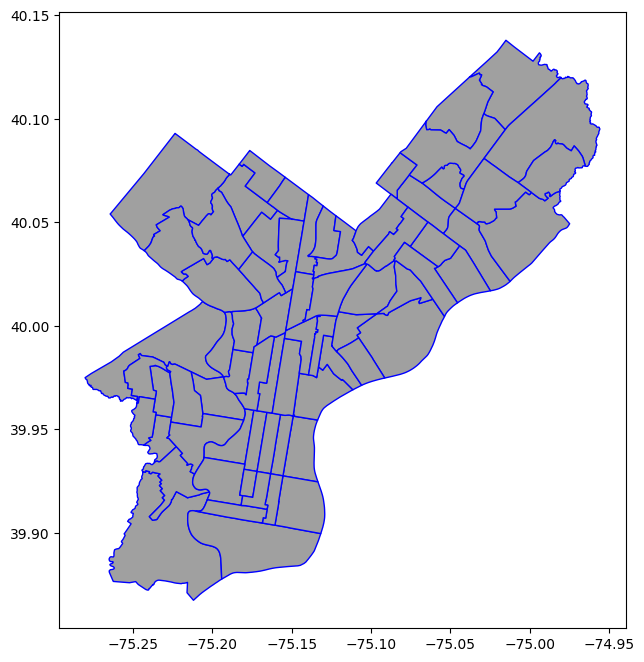

In [6]:
rub_df.plot(figsize=(16,8), color='#A0A0A0', edgecolor='blue')

In [7]:
rub_df['SANDIS'].unique()

<ArrowStringArray>
[ nan, '1A', '1B', '2B', '2D', '3C', '3F', '4G', '4M', '5F', '5L', '6A', '6B',
 '6L']
Length: 14, dtype: str

In [8]:
rub_df['SANDIS'].value_counts(dropna=False)

SANDIS
2D     6
3C     6
2B     5
1A     5
1B     5
3F     5
5L     5
4G     5
4M     5
5F     5
6B     5
6A     5
6L     5
NaN    1
Name: count, dtype: int64

In [9]:
rub_df['COLLDAY'].value_counts(dropna=False)

COLLDAY
FRI    13
MON    13
TUE    13
THU    13
WED    13
NaN     3
Name: count, dtype: int64

<Axes: >

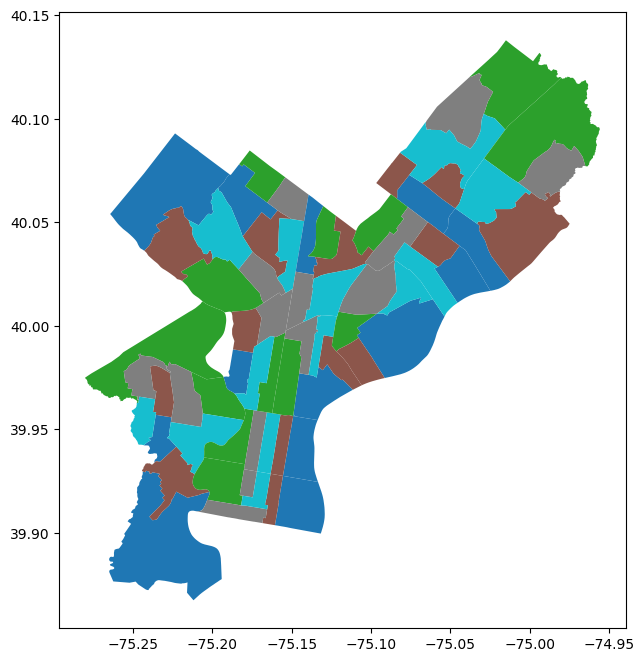

In [10]:
fig,ax=plt.subplots(figsize=(16,8))
rub_df.plot(ax=ax, column='COLLDAY', categorical=True)

* So we first need to subset the data frame to remove the rows with `None` or `NA` values.

In [11]:
rub_df2=rub_df[-rub_df['COLLDAY'].isnull()]

In [12]:
rub_df.shape

(68, 7)

In [13]:
rub_df2.shape

(65, 7)

<Axes: >

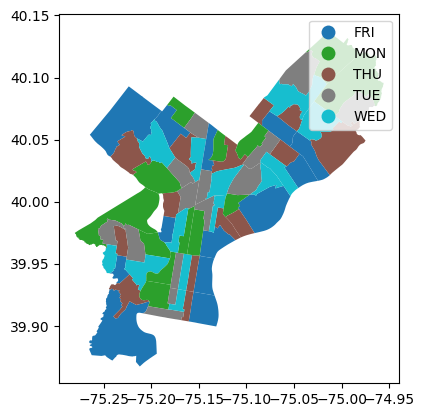

In [14]:
rub_df2.plot(column='COLLDAY', categorical=True, legend=True)

* Looking at the `geojson` version

In [15]:
rub_gj_df=gpd.read_file('data/Rubbish_Recyc_Coll_Bnd.geojson')

In [16]:
rub_gj_df.head()

,OBJECTID,DISDAY,SANDIS,COLLDAY,Shape__Area,Shape__Length,geometry
0,1,NaN,NaN,NaN,1.563566e+04,1155.512904,"MULTIPOLYGON (((-75.06524 40.09865, -75.06512 ..."
1,2,1AFRI,1A,FRI,2.489612e+07,26677.136613,"POLYGON ((-75.2283 39.94571, -75.22844 39.9457..."
2,3,1AMON,1A,MON,1.614375e+08,86552.818143,"POLYGON ((-75.20375 39.98584, -75.20335 39.986..."
3,4,1ATHU,1A,THU,2.765149e+07,24264.518128,"POLYGON ((-75.23017 39.9788, -75.2308 39.9791,..."
4,5,1ATUE,1A,TUE,3.313176e+07,32783.159394,"POLYGON ((-75.23133 39.98265, -75.2332 39.9833..."


* `GeoJson` is a format that uses `JSON` to encode geographical shape and location data.


* Here is a peek at what it looks like:

In [17]:
jdata = json.load(open('data/Rubbish_Recyc_Coll_Bnd.geojson'))

In [18]:
jstr=json.dumps(jdata, indent=4)
print(jstr[:5000])

{
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {
                "OBJECTID": 1,
                "DISDAY": null,
                "SANDIS": null,
                "COLLDAY": null,
                "Shape__Area": 15635.6585083008,
                "Shape__Length": 1155.51290395008
            },
            "geometry": {
                "type": "MultiPolygon",
                "coordinates": [
                    [
                        [
                            [
                                -75.0652382693215,
                                40.0986505917779
                            ],
                            [
                                -75.0651170387364,
                                40.0988692849685
                            ],
                            [
                                -75.0649353695417,
                                40.0991015930967
                            ],
      

In [19]:
sc_df=pd.read_csv('data/philly_sanitation_centers.csv')
sc_df

,long,lat,address
0,-75.076212,39.984366,"3901 N Delaware Ave, Philadelphia, PA 19137, U..."
1,-75.212212,39.935665,"5100 Grays Ave, Philadelphia, PA 19143, United..."
2,-75.177512,39.986436,"2601 W Glenwood Ave, Philadelphia, PA 19121, U..."
3,-75.217312,39.918265,"3033 S 63rd St, Philadelphia, PA 19153, United..."
4,-75.239012,40.039166,"300 Domino Ln, Philadelphia, PA 19128, United ..."
5,-75.011123,40.037656,"State Rd & Ashburner St, Philadelphia, PA 1913..."


In [20]:
gpd.points_from_xy(sc_df['long'],sc_df['lat'])

<GeometryArray>
[<POINT (-75.076 39.984)>, <POINT (-75.212 39.936)>, <POINT (-75.178 39.986)>,
 <POINT (-75.217 39.918)>, <POINT (-75.239 40.039)>, <POINT (-75.011 40.038)>]
Length: 6, dtype: geometry

In [21]:
sc_gdf=gpd.GeoDataFrame(sc_df,geometry=gpd.points_from_xy(sc_df['long'],sc_df['lat']))

In [22]:
sc_gdf

,long,lat,address,geometry
0,-75.076212,39.984366,"3901 N Delaware Ave, Philadelphia, PA 19137, U...",POINT (-75.07621 39.98437)
1,-75.212212,39.935665,"5100 Grays Ave, Philadelphia, PA 19143, United...",POINT (-75.21221 39.93567)
2,-75.177512,39.986436,"2601 W Glenwood Ave, Philadelphia, PA 19121, U...",POINT (-75.17751 39.98644)
3,-75.217312,39.918265,"3033 S 63rd St, Philadelphia, PA 19153, United...",POINT (-75.21731 39.91827)
4,-75.239012,40.039166,"300 Domino Ln, Philadelphia, PA 19128, United ...",POINT (-75.23901 40.03917)
5,-75.011123,40.037656,"State Rd & Ashburner St, Philadelphia, PA 1913...",POINT (-75.01112 40.03766)


<Axes: >

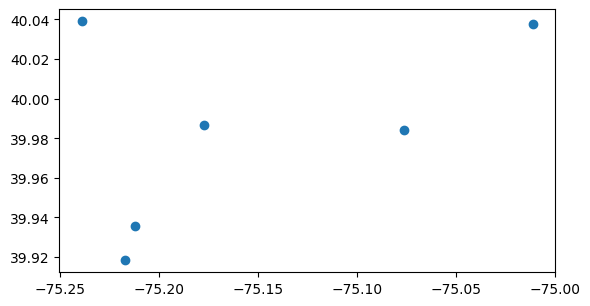

In [23]:
sc_gdf.plot()

<Axes: >

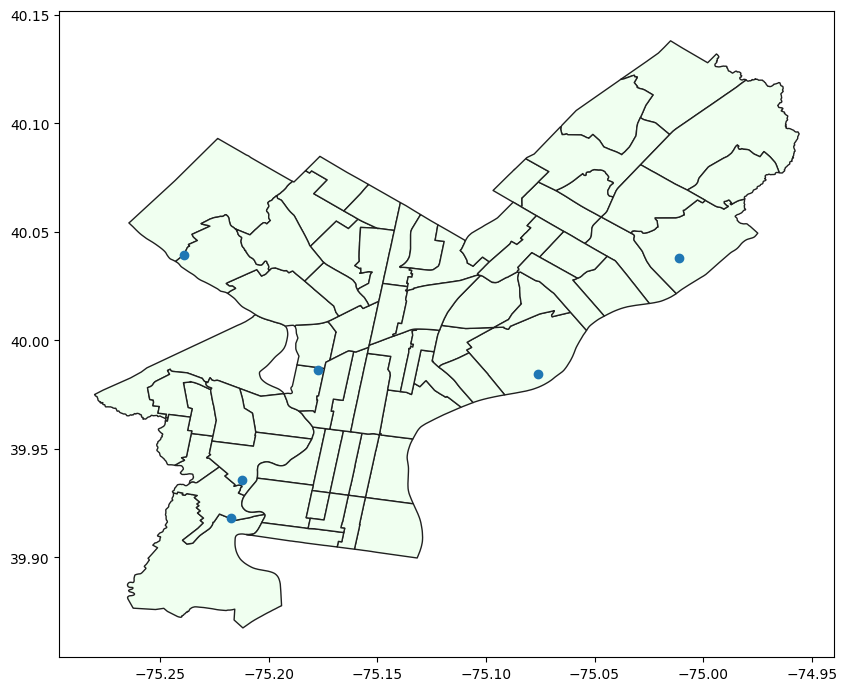

In [24]:
base=rub_df2.plot(color='#f0fff0', edgecolor='#202020', figsize=(10,10))
sc_gdf.plot(ax=base)

In [25]:
lead_df = gpd.read_file('data/child_blood_lead_levels_by_zip.geojson')

In [26]:
lead_df.head()

,zip_code,data_redacted,num_bll_5plus,num_screen,perc_5plus,geometry
0,19102,True,NaN,51,NaN,"POLYGON ((-75.16196 39.95958, -75.16206 39.959..."
1,19103,True,NaN,224,NaN,"POLYGON ((-75.17802 39.96212, -75.17524 39.960..."
2,19107,True,NaN,139,NaN,"POLYGON ((-75.15324 39.95849, -75.15205 39.958..."
3,19104,False,28.0,805,3.5,"POLYGON ((-75.20436 39.97443, -75.20372 39.974..."
4,19106,True,NaN,118,NaN,"POLYGON ((-75.15032 39.95811, -75.15013 39.958..."


<Axes: >

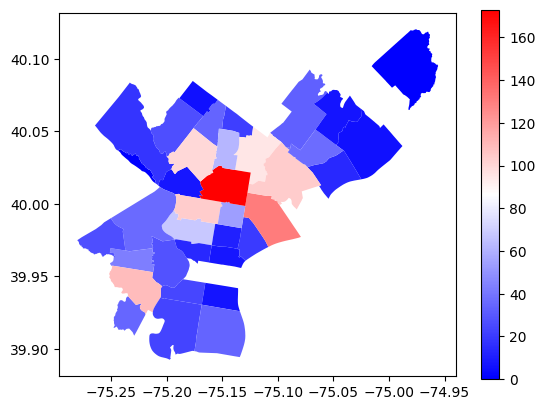

In [27]:
lead_df.plot(column='num_bll_5plus', legend=True, cmap='bwr')

In [28]:
pdiv_df = gpd.read_file('data/Political_Divisions.geojson')

In [29]:
pdiv_df.shape

(1703, 6)

In [30]:
pdiv_df.head()

,OBJECTID,SHORT_DIV_NUM,DIVISION_NUM,Shape__Area,Shape__Length,geometry
0,1,26,5826,5.065369e+05,3430.802844,"POLYGON ((-75.03855 40.10107, -75.03986 40.101..."
1,2,23,6623,2.115134e+05,1800.787144,"POLYGON ((-74.96947 40.09434, -74.97011 40.093..."
2,3,30,5830,2.417316e+05,2156.257799,"POLYGON ((-75.02519 40.09585, -75.02768 40.095..."
3,4,14,5814,4.058478e+05,3565.740136,"POLYGON ((-75.03093 40.09406, -75.03093 40.094..."
4,5,10,6610,8.039545e+06,13142.819146,"POLYGON ((-75.01537 40.09474, -75.0174 40.0926..."


<Axes: >

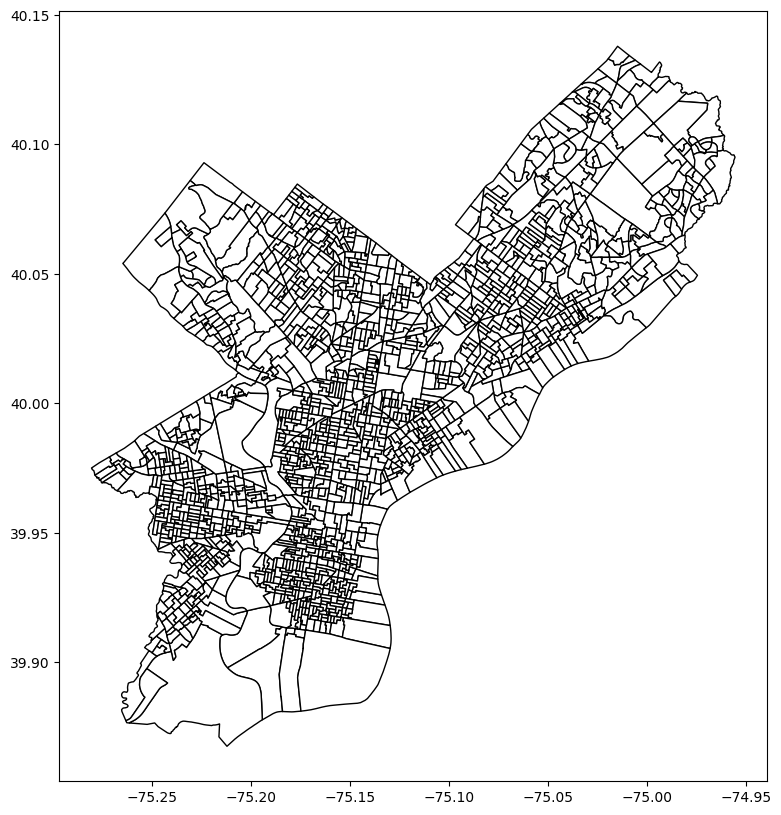

In [31]:
pdiv_df.plot(color='white', edgecolor='black', figsize=(16,10))

In [32]:
vote_df = gpd.read_file('data/qualified_voter_listing_2018_primary_by_ward.geojson')

In [33]:
vote_df.shape

(67, 13)

In [34]:
vote_df.sample(10)

,ward,dem,rep,other_party,total,white,black,hispanic,other_race,male,female,unknown_sex,geometry
8,WD09,9651,1298,1463,12412,3642,1452,142,228,4025,5319,3068,None
26,WD27,13825,1851,4929,20605,2929,2212,445,1140,7713,9004,3888,None
33,WD34,22629,984,1994,25607,1099,13178,224,465,7547,10777,7283,None
16,WD17,14511,573,1157,16241,249,9222,164,361,4884,7014,4343,None
5,WD06,8694,302,835,9831,304,5574,104,272,3074,4114,2643,None
37,WD38,10724,953,1410,13087,1960,5040,153,250,4256,5356,3475,None
15,WD16,7601,289,650,8540,119,5538,130,141,2623,3426,2491,None
13,WD14,5033,324,653,6010,430,2741,291,198,1844,2459,1707,None
35,WD36,18122,1382,2299,21803,2448,8853,365,811,7590,8641,5572,None
43,WD44,8767,265,789,9821,132,6028,85,222,2962,4035,2824,None


In [35]:
pdiv_df['ward']=pdiv_df['DIVISION_NUM'].str[:2]

In [36]:
pdiv_df.head()

,OBJECTID,SHORT_DIV_NUM,DIVISION_NUM,Shape__Area,Shape__Length,geometry,ward
0,1,26,5826,5.065369e+05,3430.802844,"POLYGON ((-75.03855 40.10107, -75.03986 40.101...",58
1,2,23,6623,2.115134e+05,1800.787144,"POLYGON ((-74.96947 40.09434, -74.97011 40.093...",66
2,3,30,5830,2.417316e+05,2156.257799,"POLYGON ((-75.02519 40.09585, -75.02768 40.095...",58
3,4,14,5814,4.058478e+05,3565.740136,"POLYGON ((-75.03093 40.09406, -75.03093 40.094...",58
4,5,10,6610,8.039545e+06,13142.819146,"POLYGON ((-75.01537 40.09474, -75.0174 40.0926...",66


In [37]:
wdiv_df=pdiv_df.dissolve(by='ward')

<Axes: >

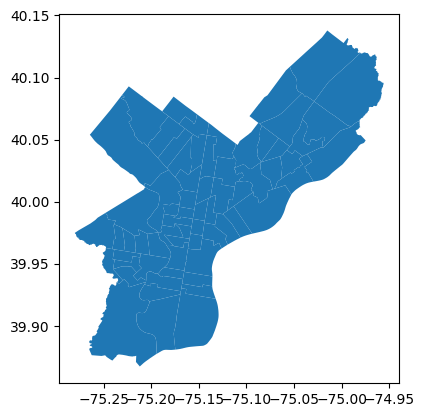

In [38]:
wdiv_df.plot()

In [39]:
wdiv_df.shape

(66, 6)

<Axes: >

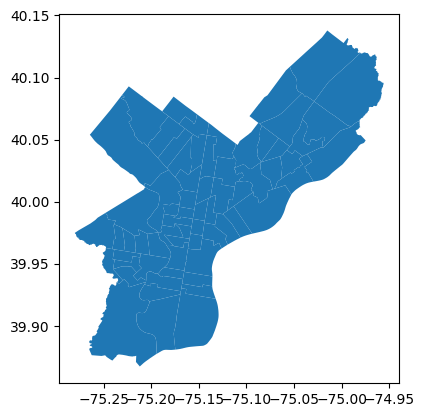

In [40]:
wdiv_df.plot()

In [41]:
vote_df['ward_num']=vote_df['ward'].str[2:]

In [42]:
vote_df.head()

,ward,dem,rep,other_party,total,white,black,hispanic,other_race,male,female,unknown_sex,geometry,ward_num
0,WD01,9401,1402,1705,12508,4446,566,393,650,4576,4927,3005,None,01
1,WD02,14247,2209,2891,19347,5590,1441,370,719,6899,7657,4791,None,02
2,WD03,12191,339,876,13406,88,8236,88,273,3946,5601,3859,None,03
3,WD04,12410,332,1019,13761,81,8690,86,267,3886,5913,3962,None,04
4,WD05,23018,4564,6717,34299,8697,2143,787,1628,12700,12421,9178,None,05


In [43]:
vdf = vote_df.merge(wdiv_df, left_on='ward_num', right_on='ward')

In [44]:
vdf

,ward,dem,rep,other_party,total,white,black,hispanic,other_race,male,female,unknown_sex,geometry_x,ward_num,geometry_y,OBJECTID,SHORT_DIV_NUM,DIVISION_NUM,Shape__Area,Shape__Length
0,WD01,9401,1402,1705,12508,4446,566,393,650,4576,4927,3005,None,01,"POLYGON ((-75.15767 39.92532, -75.15921 39.925...",1405,02,0102,84278.589844,1301.026059
1,WD02,14247,2209,2891,19347,5590,1441,370,719,6899,7657,4791,None,02,"POLYGON ((-75.15349 39.9323, -75.15396 39.9323...",1268,20,0220,98436.804688,1306.776803
2,WD03,12191,339,876,13406,88,8236,88,273,3946,5601,3859,None,03,"POLYGON ((-75.24706 39.9435, -75.24706 39.9436...",913,15,0315,116951.906250,1781.517268
3,WD04,12410,332,1019,13761,81,8690,86,267,3886,5913,3962,None,04,"POLYGON ((-75.24003 39.96188, -75.24076 39.961...",740,04,0404,133863.093750,1479.750039
4,WD05,23018,4564,6717,34299,8697,2143,787,1628,12700,12421,9178,None,05,"POLYGON ((-75.1481 39.9415, -75.14918 39.94163...",1205,22,0522,61183.296875,1117.878063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,WD62,12743,1498,1764,16005,2409,4278,2639,477,4978,6648,4379,None,62,"POLYGON ((-75.07438 40.01541, -75.07471 40.016...",342,24,6224,338375.449219,2703.100894
62,WD63,8307,5338,1595,15240,6834,563,570,564,5173,6242,3825,None,63,"POLYGON ((-75.0734 40.06702, -75.07371 40.0669...",9,17,6317,457401.292969,3316.296751
63,WD64,5648,3048,1065,9761,4197,538,507,232,3229,3804,2728,None,64,"POLYGON ((-75.04254 40.03773, -75.0442 40.0386...",127,15,6415,593904.449219,4739.066462
64,WD65,9334,3341,1441,14116,5614,1457,888,343,4782,5811,3523,None,65,"POLYGON ((-75.00086 40.02897, -75.00623 40.025...",224,09,6509,321731.402344,2631.302613


In [45]:
vote_gdf=gpd.GeoDataFrame(vdf, geometry='geometry_y')

In [46]:
vote_gdf.shape

(66, 20)

In [47]:
vote_gdf['rep_per']=vote_gdf['rep']  / vote_gdf['total']

<Axes: >

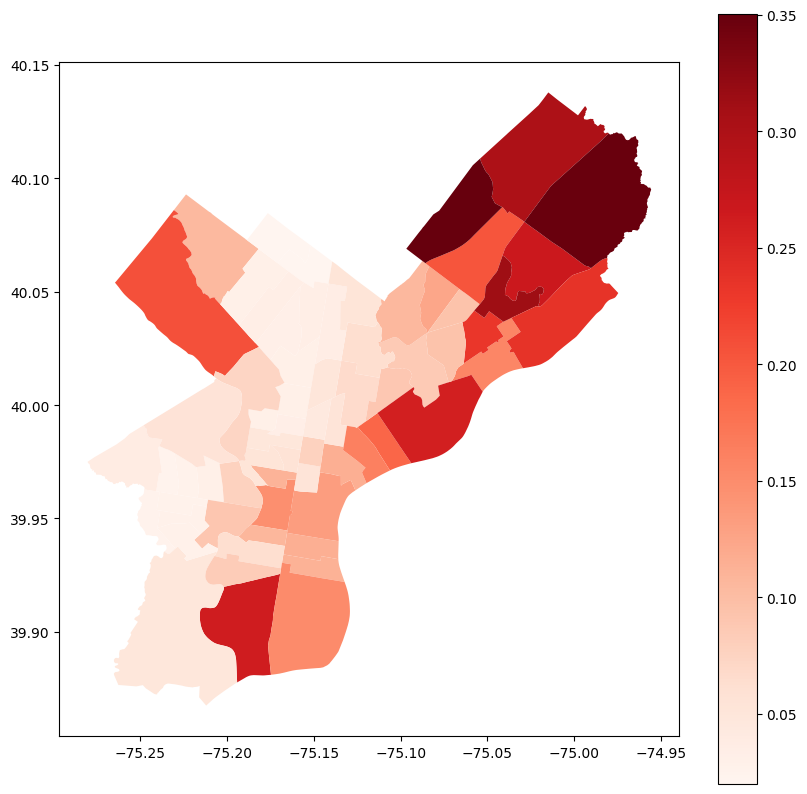

In [48]:
vote_gdf.plot(column='rep_per', figsize=(10,10), cmap='Reds', legend=True)